# Variable 1: Democracy (Polity IV → Polity V SSA Extension)
## Data Sources

This notebook uses two main datasets:

| Data | Source | Citation | Notes |
|------|---------|-----------|--------|
| **Original dataset (`database.dta`)** | Provided from Brückner & Ciccone (2011) replication files | Brückner & Ciccone, *Econometrica* (2011) | Contains democracy, rainfall, and income variables up to 2004 |
| **Updated Polity V dataset (`p5v2018.xlsx`)** | [Center for Systemic Peace – Polity Project](https://www.systemicpeace.org/inscrdata.html) | Marshall, Gurr & Jaggers (2020) | Extends democracy scores to 2018 (Polity2, Exconst, Polcomp, Exrec) |



In [17]:
# ============================
# Load the original dataset
# ============================

# File: database.dta (uploaded in this workspace)
# ------------------------------------------------
# This Stata dataset contains all variables used in the paper.
# We'll read it into pandas using the read_stata() function.
import pandas as pd
database = pd.read_stata("data/raw/original/database.dta")

# Display basic information
print("✅ Original dataset loaded successfully!")
print(f"Number of rows: {len(database):,}")
print(f"Number of columns: {len(database.columns)}")

# Preview the first few rows
database.head()


✅ Original dataset loaded successfully!
Number of rows: 961
Number of columns: 116


,country,countryisocode,year,ccode,polity2,polity2l,polity2l2,polity_d,polity,exconst,...,dum_rain_10,dum_rain_20,agri_gdpshare,agri_gdp_av,gdp_l2,rain_mw_l,rain_mw_l3,rain_mw_l4,rain_mw_l2,rain_mw
0,Guinea-Bissau,GNB,1981,404,-7.0,-7.0,-7.0,0.0,-7,3.0,...,0,1,53.279999,53.743752,338.047333,1323.417725,1796.730103,1222.450684,1343.365479,1711.137573
1,Guinea-Bissau,GNB,1982,404,-7.0,-7.0,-7.0,0.0,-7,3.0,...,1,1,46.770000,53.743752,313.258240,1711.137573,1343.365234,1796.730103,1323.417969,1469.449951
2,Guinea-Bissau,GNB,1983,404,-7.0,-7.0,-7.0,0.0,-7,3.0,...,0,0,42.450001,53.743752,417.014160,1469.449951,1323.417725,1343.365234,1711.137939,1342.599365
3,Guinea-Bissau,GNB,1984,404,-8.0,-7.0,-7.0,0.0,-8,2.0,...,0,0,41.320000,53.743752,409.886810,1342.599365,1711.137573,1323.417725,1469.450073,1348.143433
4,Guinea-Bissau,GNB,1985,404,-8.0,-8.0,-7.0,0.0,-8,2.0,...,1,1,46.490002,53.743752,450.310425,1348.143433,1469.449951,1711.137573,1342.599609,1400.806152


## Extract Country Information

We now identify the unique list of countries included in the Brückner & Ciccone (2011) sample.
These countries form the basis for filtering the updated Polity V dataset.


In [18]:
# ==================================
# 4. Extract list of unique countries
# ==================================

# Check possible variable names for country identifiers
print("Column names:", list(database.columns))

# Common variable names: 'country', 'countryname', or 'ccode'
# Adjust this line if your dataset uses a different column name.
country_col = [col for col in database.columns if 'country' in col.lower()][0]

# Extract unique list of countries
country_list = sorted(database[country_col].dropna().unique())

print(f"✅ Extracted {len(country_list)} unique countries from original dataset.")
print(country_list) 


Column names: ['country', 'countryisocode', 'year', 'ccode', 'polity2', 'polity2l', 'polity2l2', 'polity_d', 'polity', 'exconst', 'exconst_l', 'polcomp', 'polcomp_l', 'exrec', 'exrec_l', 'polity_change', 'exconst_change', 'polcomp_change', 'exrec_change', 'trans_democ', 'trans_democ_epst', 'trans_autoc', 'democ_prez', 'democ_prez_l', 'trans_democ_prez', 'trans_autoc_prez', 'polright', 'polright_l', 'polright_l2', 'civliberty', 'civliberty_l', 'civliberty_l2', 'fh_av', 'fh_av_l', 'fh_av_l2', 'free', 'free_l', 'free_l2', 'gpcp', 'lgpcp_l', 'lgpcp_l2', 'lgpcp_l3', 'gdp', 'lgdp_l', 'lgdp_l2', 'lgdp_l3', 'gpcp_g_l', 'gdp_g_l', 'lgpcp_l2polity2l2', 'polity_l', 'lgpcp_l4', 'polright_change', 'coup', 'recession_l', 'recession_l2', 'recession_l3', 'lrain_mw_l', 'lrain_mw_l2', 'lrain_mw_l3', 'lrain_mw_l4', 'lgdp_l4', 'polity2l3', 'lgpcp_l_spat', 'lgpcp_l2_spat', 'lgpcp_l3_spat', 'temp_mw', 'temp_mw_l', 'temp_mw_l2', 'temp_mw_l3', 'gdp_g_l2', 'gpcp_l2', 'gpcp_l3', 'gpcp_l4', 'gpcp_l', 'lgdp', 'gp

Load the Updated Polity V Dataset (Sub-Saharan Africa, 2005–2018)

We now load the updated democracy data from the Polity V Project (Marshall, Gurr & Jaggers, 2020).
This dataset extends the Polity IV coverage beyond 2004 for all Sub-Saharan African countries.
It includes the same key variables — polity2, exconst, polcomp, and exrec — with harmonized definitions, allowing us to seamlessly merge it with the original dataset.

In [19]:
polity = pd.read_csv("data/raw/polity/polity5_SSA_2005_2018.csv")
print(polity.head())

  country  year  polity2  exconst  polcomp  exrec
0  Angola  2005     -2.0        3      8.0    3.0
1  Angola  2006     -2.0        3      8.0    3.0
2  Angola  2007     -2.0        3      8.0    3.0
3  Angola  2008     -2.0        3      8.0    3.0
4  Angola  2009     -2.0        3      8.0    3.0


## Variable 2: Real GDP per Capita (Penn World Table Extension)

### **Source and Description**

- **Dataset:** Penn World Table (PWT) — latest version **10.01**  
  *(Feenstra, Inklaar & Timmer, University of Groningen, 2025)*  
- **Original dataset in paper:** PWT 6.2, which ended in 2004.  
- **Extension period:** **2005 – latest available year** (as of 2025).  
- **Main variables:**
  - `rgdpe` — Real GDP at constant 2017 national prices (millions of 2017 USD).  
  - `pop` — Population (persons).  
- **Constructed variable:**  
  \[
  \text{rgdpe\_pc} = \frac{\text{rgdpe} \times 10^6}{\text{pop}}
  \]
  representing *real GDP per capita* in constant 2017 USD.

### **Methodological Notes**

- PWT 10.01 expresses GDP in **2017 constant prices**, unlike older versions that used 2005 USD.  
- The new PPP methodology and revised national accounts improve comparability across countries and years.  
- Within-version comparisons remain valid, but cross-version comparisons (e.g., between 6.2 and 10.01) should be treated cautiously.

### **Data Access**

- **Source:** [Penn World Table (PWT 10.01)](https://www.rug.nl/ggdc/productivity/pwt/)  
- **Accessed:** October 2025  
- **File:** `pwt110.xlsx` (Sheet = "Data")

### **Construction Steps**

1. Load `pwt110.xlsx`.  
2. Keep variables `countrycode`, `country`, `year`, `rgdpe`, and `pop`.  
3. Restrict to years ≥ 2005.  
4. Compute real GDP per capita (`rgdpe_pc`).  
5. Output a clean dataset with four columns:
   - `countrycode`
   - `country`
   - `year`
   - `rgdpe_pc`

### **Integration Notes**

- Merge key: `countrycode` + `year`.  
- Use `rgdpe_pc` as the consistent GDP per capita variable in 2017 USD.  
- This table will later be merged into the main `database.dta` structure.

---


In [20]:
# Variable 2: Real GDP per Capita (PWT 11.0)
# File: pwt110.xlsx | Sheet: Data
import pandas as pd
from pathlib import Path

# ---- Step 0: Resolve path (try common locations) ----
possible_paths = [
    Path("data/raw/pwt/pwt110.xlsx"),
]
pwt_path = next((p for p in possible_paths if p.exists()), possible_paths[0])

# ---- Step 1: Load the 'Data' sheet (case-insensitive fallback) ----
def _read_pwt_data(path: Path) -> pd.DataFrame:
    try:
        return pd.read_excel(path, sheet_name="Data")
    except Exception:
        # Some copies may label it 'data' (lowercase)
        return pd.read_excel(path, sheet_name="data")

pwt = _read_pwt_data(pwt_path)

# ---- Step 2: Select relevant variables ----
keep_cols = ["countrycode", "country", "year", "rgdpe", "pop"]
missing = [c for c in keep_cols if c not in pwt.columns]
if missing:
    raise ValueError(f"Missing expected columns in PWT: {missing}")

pwt_vars = pwt[keep_cols].copy()

# ---- Step 3: Type safety & basic cleaning ----
# Coerce numerics in case the sheet has mixed types
pwt_vars["year"]  = pd.to_numeric(pwt_vars["year"], errors="coerce")
pwt_vars["rgdpe"] = pd.to_numeric(pwt_vars["rgdpe"], errors="coerce")
pwt_vars["pop"]   = pd.to_numeric(pwt_vars["pop"],   errors="coerce")

# Drop rows with missing key fields
pwt_vars = pwt_vars.dropna(subset=["countrycode", "year", "rgdpe", "pop"])

# ---- Step 4: Restrict to extension period (>= 2005) ----
pwt_ext = pwt_vars[pwt_vars["year"] >= 2005].copy()

# ---- Step 5: Construct Real GDP per capita (constant 2017 USD) ----
# rgdpe is in millions of 2017 USD
pwt_ext["rgdpe_pc"] = (pwt_ext["rgdpe"] * 1_000_000) / pwt_ext["pop"]

# ---- Step 6: Final tidy table ----
pwt_extension_final = (
    pwt_ext[["countrycode", "country", "year", "rgdpe_pc"]]
    .sort_values(["countrycode", "year"])
    .reset_index(drop=True)
)

# ---- Quick peek ----
pwt_extension_final.head()


,countrycode,country,year,rgdpe_pc
0,ABW,Aruba,2005,5.444239e+10
1,ABW,Aruba,2006,5.458371e+10
2,ABW,Aruba,2007,5.559177e+10
3,ABW,Aruba,2008,5.468561e+10
4,ABW,Aruba,2009,4.838713e+10


## Variable 3: Rainfall (GPCP Aggregation and Reconstruction)

### Data Source
We reconstruct the rainfall variable using NASA’s **Global Precipitation Climatology Project (GPCP)**  
**Monthly Precipitation Data, Version 2.3**, available from **NOAA NCEI**:

- **Dataset:** [GPCP Monthly Precipitation CDR V2.3 (2.5° × 2.5° grid)](https://www.ncei.noaa.gov/data/global-precipitation-climatology-project-gpcp-monthly/access/)
- **Coverage:** January 1979 – present (ongoing)
- **Units:** mm/day  
- **Resolution:** 2.5° × 2.5°  
- **Format:** NetCDF (`.nc`)  
- **Example files used here:** January–December 2005 (`gpcp_v02r03_monthly_d2005*.nc`)

We downloaded all 12 monthly files for 2005 and will:

1. Inspect and visualize the grid data.  
2. Convert monthly rainfall (mm/day) into annual totals (mm/year).  
3. Prepare this for country-level aggregation (next section).

In [21]:
import os
import requests

base_url = "https://www.ncei.noaa.gov/data/global-precipitation-climatology-project-gpcp-monthly/access/2005/"
months = [f"{m:02d}" for m in range(1, 13)]

os.makedirs("data/raw/gpcp/2005", exist_ok=True)

for m in months:
    file_name = f"gpcp_v02r03_monthly_d2005{m}_c20170616.nc"
    url = base_url + file_name
    r = requests.get(url)
    if r.status_code == 200:
        with open(f"data/raw/gpcp/2005/{file_name}", "wb") as f:
            f.write(r.content)
        print(f"Downloaded {file_name}")
    else:
        print(f"Failed to download {file_name}")


Downloaded gpcp_v02r03_monthly_d200501_c20170616.nc
Downloaded gpcp_v02r03_monthly_d200502_c20170616.nc
Downloaded gpcp_v02r03_monthly_d200503_c20170616.nc
Downloaded gpcp_v02r03_monthly_d200504_c20170616.nc
Downloaded gpcp_v02r03_monthly_d200505_c20170616.nc
Downloaded gpcp_v02r03_monthly_d200506_c20170616.nc
Downloaded gpcp_v02r03_monthly_d200507_c20170616.nc
Downloaded gpcp_v02r03_monthly_d200508_c20170616.nc
Downloaded gpcp_v02r03_monthly_d200509_c20170616.nc
Downloaded gpcp_v02r03_monthly_d200510_c20170616.nc
Downloaded gpcp_v02r03_monthly_d200511_c20170616.nc
Downloaded gpcp_v02r03_monthly_d200512_c20170616.nc


Import required packages

In [22]:
!pip install xarray netCDF4 matplotlib numpy

In [23]:
# Core packages for data handling and visualization
import xarray as xr          # to open and process NetCDF files
import numpy as np           # for numerical operations
import matplotlib.pyplot as plt  # for plotting


Open a sample monthly file to inspect metadata

In [24]:
# Open one sample month (January 2005)
ds = xr.open_dataset("data/raw/gpcp/2005/gpcp_v02r03_monthly_d200501_c20170616.nc")

# Display dataset structure and metadata
ds


<xarray.Dataset>
Dimensions:       (latitude: 72, longitude: 144, time: 1, nv: 2)
Coordinates:
  * latitude      (latitude) float32 -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * longitude     (longitude) float32 1.25 3.75 6.25 8.75 ... 353.8 356.2 358.8
  * time          (time) datetime64[ns] 2005-01-01
Dimensions without coordinates: nv
Data variables:
    lat_bounds    (latitude, nv) float32 ...
    lon_bounds    (longitude, nv) float32 ...
    time_bounds   (time, nv) datetime64[ns] ...
    precip        (time, latitude, longitude) float32 ...
    precip_error  (time, latitude, longitude) float32 ...
Attributes: (12/45)
    Conventions:                CF-1.6, ACDD 1.3
    title:                      Global Precipitation Climatatology Project (G...
    source:                     oc.200501.sg
    references:                 Huffman et al. 1997, http://dx.doi.org/10.117...
    history:                    1) `o�, Dr. Jian-Jian Wang, U of Maryland,...
    Metadata_Conventions:       CF-1.6, Unidata Dataset Discovery v1.0, NOAA ...
    ...                         ...
    metadata_link:              gov.noaa.ncdc:C00979
    product_version:            v23rB1
    platform:                   GOES (Geostationary Operational Environmental...
    sensor:                     Imager, Imager, Imager, TOVS > TIROS Operatio...
    spatial_resolution:         2.5 degree
    comment:                    Processing computer: eagle2.umd.edu

Visualize one month’s rainfall distribution

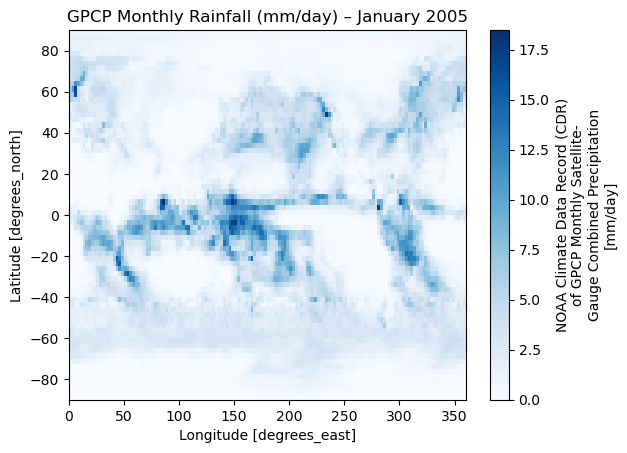

In [25]:
# Access precipitation variable (name differs in some versions)
precip = ds['precip'] if 'precip' in ds else ds['precipitation']

# Plot January 2005 rainfall map
precip.isel(time=0).plot(cmap='Blues')
plt.title("GPCP Monthly Rainfall (mm/day) – January 2005")
plt.show()


Open all monthly files for 2005

In [26]:
# Combine all 12 months (xarray merges by time automatically)
ds_all = xr.open_mfdataset("data/raw/gpcp/2005/*.nc", combine='by_coords')

# Check structure: should show 12 time steps (one per month)
ds_all


<xarray.Dataset>
Dimensions:       (latitude: 72, longitude: 144, time: 12, nv: 2)
Coordinates:
  * latitude      (latitude) float32 -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * longitude     (longitude) float32 1.25 3.75 6.25 8.75 ... 353.8 356.2 358.8
  * time          (time) datetime64[ns] 2005-01-01 2005-02-01 ... 2005-12-01
Dimensions without coordinates: nv
Data variables:
    lat_bounds    (time, latitude, nv) float32 dask.array<chunksize=(1, 72, 2), meta=np.ndarray>
    lon_bounds    (time, longitude, nv) float32 dask.array<chunksize=(1, 144, 2), meta=np.ndarray>
    time_bounds   (time, nv) datetime64[ns] dask.array<chunksize=(1, 2), meta=np.ndarray>
    precip        (time, latitude, longitude) float32 dask.array<chunksize=(1, 72, 144), meta=np.ndarray>
    precip_error  (time, latitude, longitude) float32 dask.array<chunksize=(1, 72, 144), meta=np.ndarray>
Attributes: (12/45)
    Conventions:                CF-1.6, ACDD 1.3
    title:                      Global Precipitation Climatatology Project (G...
    source:                     oc.200501.sg
    references:                 Huffman et al. 1997, http://dx.doi.org/10.117...
    history:                    1) `o�, Dr. Jian-Jian Wang, U of Maryland,...
    Metadata_Conventions:       CF-1.6, Unidata Dataset Discovery v1.0, NOAA ...
    ...                         ...
    metadata_link:              gov.noaa.ncdc:C00979
    product_version:            v23rB1
    platform:                   GOES (Geostationary Operational Environmental...
    sensor:                     Imager, Imager, Imager, TOVS > TIROS Operatio...
    spatial_resolution:         2.5 degree
    comment:                    Processing computer: eagle2.umd.edu

- Convert mm/day → mm/year
- Because GPCP gives rainfall as mm/day, multiplying by the number of days in each month yields total precipitation (mm) per month.
- Summing all 12 months gives the total annual rainfall (mm/year) for each grid cell.

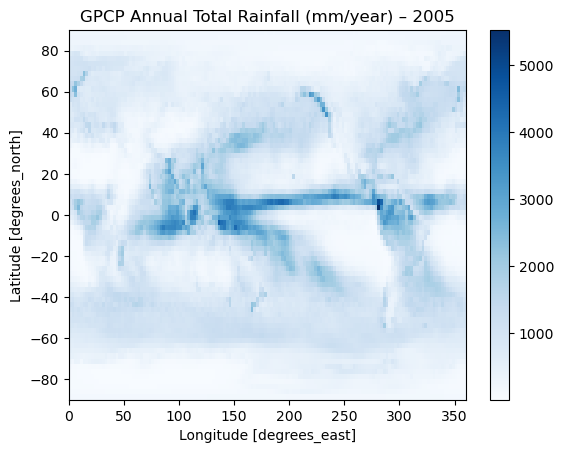

In [27]:
# Compute number of days in each month from the time coordinate
ds_all['days_in_month'] = ds_all['time'].dt.days_in_month

# Calculate monthly totals (mm/month)
monthly_total = ds_all['precip'] * ds_all['days_in_month']

# Sum across all 12 months to get annual total (mm/year)
annual_2005 = monthly_total.sum(dim='time')

# Visualize annual total rainfall
annual_2005.plot(cmap='Blues')
plt.title("GPCP Annual Total Rainfall (mm/year) – 2005")
plt.show()


### Load Country Boundaries (Updated for GeoPandas ≥1.0)

Since the built-in dataset `naturalearth_lowres` was removed, we manually use the official  
**Natural Earth 1:50m Administrative Boundaries** shapefile, available here:

🔗 https://www.naturalearthdata.com/downloads/50m-cultural-vectors/50m-admin-0-countries/

After downloading, extract the zip file (e.g., `ne_50m_admin_0_countries.shp`) into your `data/` folder.



In [ ]:
!pip install geopandas shapely fiona pyproj rtree


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.4/338.4 kB 2.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 1.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 2.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 1.9 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 2.7 MB/s eta 0:00:0000:0100:01


In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point

# --- Step 1: Load Natural Earth shapefile (downloaded manually) ---
# Path to your local shapefile; adjust if saved elsewhere
countries = gpd.read_file("data/raw/shapefiles/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp")

# Keep ISO3 code, name, and geometry columns
countries = countries[['ADM0_A3', 'NAME_EN', 'geometry']].rename(
    columns={'ADM0_A3': 'iso3', 'NAME_EN': 'name'}
)

# --- Step 2: Convert rainfall grid (annual_2005) to GeoDataFrame ---
rain_df = annual_2005.to_dataframe(name='rain_mm_year').reset_index()
rain_gdf = gpd.GeoDataFrame(
    rain_df,
    geometry=gpd.points_from_xy(rain_df['longitude'], rain_df['latitude']),
    crs='EPSG:4326'
)

# --- Step 3: Spatial join ---
rain_joined = gpd.sjoin(rain_gdf, countries, how='inner', predicate='within')

# --- Step 4: Aggregate ---
country_rain_2005 = (
    rain_joined.groupby('iso3')['rain_mm_year']
    .mean()
    .reset_index()
)
country_rain_2005['year'] = 2005

# --- Optional area-weighted version ---
rain_joined['weight'] = np.cos(np.radians(rain_joined['latitude']))
country_rain_weighted_2005 = (
    rain_joined.groupby('iso3')
    .apply(lambda x: np.average(x['rain_mm_year'], weights=x['weight']))
    .reset_index(name='rain_mm_year')
)
country_rain_weighted_2005['year'] = 2005

# --- Step 5: Save ---
country_rain_2005.to_csv("data/processed/country_rainfall_2005.csv", index=False)
country_rain_weighted_2005.to_csv("data/processed/country_rainfall_weighted_2005.csv", index=False)


/var/folders/w1/09wvvvcx77gccvy2hp9klkg80000gn/T/ipykernel_25161/440499195.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.average(x['rain_mm_year'], weights=x['weight']))


In [31]:
# Identify which column stores ISO3 codes
iso_col = [col for col in database.columns if 'iso' in col.lower()][0]
print("Using ISO3 column:", iso_col)

# Get the list of ISO3 codes from the original paper's country sample
iso3_list = database[iso_col].dropna().unique().tolist()
print(f"Loaded {len(iso3_list)} ISO3 country codes from original dataset.")

# Filter rainfall data by ISO3 instead of country names
country_rain_2005 = country_rain_2005[country_rain_2005['iso3'].isin(iso3_list)]
country_rain_weighted_2005 = country_rain_weighted_2005[country_rain_weighted_2005['iso3'].isin(iso3_list)]

# Save filtered datasets
country_rain_2005.to_csv("data/processed/country_rainfall_2005_ssa.csv", index=False)
country_rain_weighted_2005.to_csv("data/processed/country_rainfall_weighted_2005_ssa.csv", index=False)

print("✅ Filtered rainfall data saved for original SSA sample (matched by ISO3 codes).")



Using ISO3 column: countryisocode
Loaded 41 ISO3 country codes from original dataset.
✅ Filtered rainfall data saved for original SSA sample (matched by ISO3 codes).
